GPU not detected. Using CPU.
Image generation may take a long time on CPU.

Loading text generation model...


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.
[transformers] The model 'T5ForConditionalGeneration' is not supported for text-generation. Supported models are ['PeftModelForCausalLM', 'AfmoeForCausalLM', 'ApertusForCausalLM', 'ArceeForCausalLM', 'AriaTextForCausalLM', 'BambaForCausalLM', 'BartForCausalLM', 'BertLMHeadModel', 'BertGenerationDecoder', 'BigBirdForCausalLM', 'BigBirdPegasusForCausalLM', 'BioGptForCausalLM', 'BitNetForCausalLM', 'BlenderbotForCausalLM', 'BlenderbotSmallForCausalLM', 'BloomForCausalLM', 'BltForCausalLM', 'CamembertForCausalLM', 'CodeGenForCausalLM', 'CohereForCausalLM', 'Cohere2ForCausalLM', 'Cohere2MoeForCausalLM', 'CpmAntForCausalLM', 'CTRLLMHeadModel', 'CwmForCausalLM', 'Data2VecTextForCausalLM', 'DbrxForCausalLM',

Text model loaded successfully!

Loading Stable Diffusion model...


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

...

Image model loaded successfully!
Enter a content topic: moon

Generating text...


[transformers] Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Generating image...
Please wait...


  0%|          | 0/30 [00:00<?, ?it/s]


GENERATED TEXT

Write a short article of about 120 words on the topic:

moon

Include:
1. Introduction
2. Importance
3. Applications
Earth. It is the closest planet to the Sun, and the closest to the Sun. It is the closest planet to the Sun, and the closest to the Sun. It is the closest planet to the Sun, and the closest to the Sun. It is the closest planet to the Sun, and the closest to the Sun. It is the closest planet to the Sun, and the closest to the Sun. It is the closest planet to the Sun, and the closest to the Sun. It is the closest planet to the Sun, and the closest to the Sun. It is the closest planet to the Sun, and the closest to the Sun. It is the closest planet to the Sun, and the closest to the Sun. It is the closest planet to the Sun, and

GENERATED IMAGE


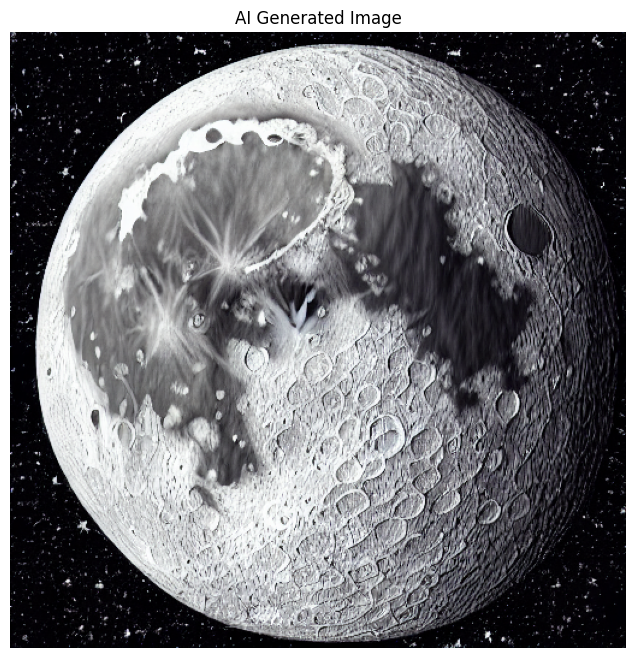


Image saved as: generated_content_image.png


In [3]:
import torch
import matplotlib.pyplot as plt

from transformers import pipeline
from diffusers import StableDiffusionPipeline


# ============================================================
# CHECK DEVICE
# ============================================================

if torch.cuda.is_available():
    device = "cuda"
    dtype = torch.float16
    print("GPU detected:", torch.cuda.get_device_name(0))
else:
    device = "cpu"
    dtype = torch.float32
    print("GPU not detected. Using CPU.")
    print("Image generation may take a long time on CPU.")


# ============================================================
# LOAD TEXT GENERATION MODEL
# ============================================================

print("\nLoading text generation model...")

text_generator = pipeline(
    "text-generation",
    model="google/flan-t5-base",
    device=0 if device == "cuda" else -1
)

print("Text model loaded successfully!")


# ============================================================
# LOAD IMAGE GENERATION MODEL
# ============================================================

print("\nLoading Stable Diffusion model...")

image_generator = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=dtype
)

image_generator = image_generator.to(device)

# Optional memory optimization
if device == "cuda":
    image_generator.enable_attention_slicing()

print("Image model loaded successfully!")


# ============================================================
# GET TOPIC FROM USER
# ============================================================

topic = input("Enter a content topic: ")


# ============================================================
# GENERATE TEXT
# ============================================================

text_prompt = f"""
Write a short article of about 120 words on the topic:

{topic}

Include:
1. Introduction
2. Importance
3. Applications
"""

print("\nGenerating text...")

text_result = text_generator(
    text_prompt,
    max_new_tokens=180,
    do_sample=False
)

generated_text = text_result[0]["generated_text"]


# ============================================================
# GENERATE IMAGE
# ============================================================

image_prompt = f"""
A realistic, high-quality illustration representing {topic},
professional digital art,
highly detailed,
realistic lighting,
sharp details,
4K quality
"""

print("\nGenerating image...")
print("Please wait...")

generated_image = image_generator(
    prompt=image_prompt,
    num_inference_steps=30,
    guidance_scale=7.5
).images[0]


# ============================================================
# SAVE IMAGE
# ============================================================

image_path = "generated_content_image.png"

generated_image.save(image_path)


# ============================================================
# DISPLAY GENERATED TEXT
# ============================================================

print("\n" + "=" * 60)
print("GENERATED TEXT")
print("=" * 60)

print(generated_text)


# ============================================================
# DISPLAY GENERATED IMAGE
# ============================================================

print("\n" + "=" * 60)
print("GENERATED IMAGE")
print("=" * 60)

plt.figure(figsize=(8, 8))

plt.imshow(generated_image)

plt.axis("off")

plt.title("AI Generated Image")

plt.show()


# ============================================================
# CONFIRM IMAGE SAVED
# ============================================================

print("\nImage saved as:", image_path)